In [179]:
# Install dependencies (re-run safe: skip if already installed)
try:
    import pg8000
    import pandas
    import numpy
    import matplotlib
except ImportError:
    import subprocess
    subprocess.check_call(["pip", "install", "pg8000", "pandas", "numpy", "matplotlib"])

import pg8000.dbapi as pgdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime

In [180]:
# Configuration — fill in your Cloud SQL credentials (or load from env / .env)
DB_HOST = "136.117.229.238"      # Cloud SQL public IP, or 127.0.0.1 if using Cloud SQL Proxy
DB_PORT = 5432
DB_NAME = "postgres"
DB_USERNAME = "postgres"
DB_PASSWORD = "priyankaDavar1996!1"

In [181]:
# Establish direct TCP connection to Cloud SQL Postgres
try:
    conn = pgdb.connect(
        host=DB_HOST,
        port=DB_PORT,
        database=DB_NAME,
        user=DB_USERNAME,
        password=DB_PASSWORD,
    )
    print("Connected successfully.")
except Exception as e:
    print(f"Connection failed: {e}")
    raise

Connected successfully.


In [182]:
# Cold-start logic removed (no longer used).

In [183]:
# Query timestamp + inference_time; normalize to UTC; filter from 2025-12-19
cursor = conn.cursor()
cursor.execute(
    """SELECT timestamp, inference_time
       FROM logging.logger_final
       WHERE inference_time IS NOT NULL AND timestamp IS NOT NULL
       ORDER BY timestamp"""
)
rows = cursor.fetchall()
cursor.close()

df = pd.DataFrame(rows, columns=["timestamp", "inference_time"])
df["timestamp"] = pd.to_datetime(df["timestamp"])
if df["timestamp"].dt.tz is None:
    df["timestamp"] = df["timestamp"].dt.tz_localize("UTC", ambiguous="infer")
else:
    df["timestamp"] = df["timestamp"].dt.tz_convert("UTC")

# Restrict to 2025-12-19 onward
df = df[df["timestamp"] >= pd.Timestamp("2025-12-19", tz="UTC")]

df["month"] = df["timestamp"].dt.to_period("M").astype(str)
inference_times = df["inference_time"]

print(f"Total rows: {len(df)}")
print(df[["timestamp", "inference_time"]].head(10))
print("\nSummary:")
print(inference_times.describe())

Total rows: 182
                    timestamp  inference_time
192 2025-12-19 18:37:02+00:00       12.252443
193 2025-12-22 04:04:24+00:00        8.232297
194 2025-12-22 04:05:02+00:00        3.144853
195 2025-12-28 17:31:21+00:00        5.369528
196 2025-12-28 17:31:40+00:00        4.626146
197 2025-12-29 23:11:02+00:00        7.024029
198 2025-12-29 23:18:33+00:00        5.885716
199 2025-12-31 21:22:36+00:00        7.014846
200 2025-12-31 21:24:54+00:00       78.462215
201 2026-01-06 19:36:42+00:00       10.311999

Summary:
count    182.000000
mean      10.423320
std       15.531323
min        0.643556
25%        4.276632
50%        6.264854
75%        9.769384
max       92.134059
Name: inference_time, dtype: float64


/var/folders/j5/9qw1sp3j5yvdfl0r334_ctw80000gn/T/ipykernel_18620/3536900677.py:22: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["month"] = df["timestamp"].dt.to_period("M").astype(str)


In [184]:
# E2E latencies > 40 s: timestamp and latency of each sample
HIGH_LATENCY_THRESHOLD = 40  # seconds
high = df[df["inference_time"] > HIGH_LATENCY_THRESHOLD].copy()
high = high.sort_values("timestamp").reset_index(drop=True)

print(f"E2E samples with latency > {HIGH_LATENCY_THRESHOLD} s: {len(high)}")
print()
for i, row in high.iterrows():
    ts = row["timestamp"]
    lat = row["inference_time"]
    print(f"  Sample: {ts}  |  Latency: {lat:.2f} s")

E2E samples with latency > 40 s: 8

  Sample: 2025-12-31 21:24:54+00:00  |  Latency: 78.46 s
  Sample: 2026-01-31 21:27:36+00:00  |  Latency: 81.08 s
  Sample: 2026-02-06 21:20:45+00:00  |  Latency: 65.43 s
  Sample: 2026-02-07 01:16:02+00:00  |  Latency: 78.61 s
  Sample: 2026-02-07 02:11:57+00:00  |  Latency: 81.93 s
  Sample: 2026-02-12 01:22:57+00:00  |  Latency: 74.80 s
  Sample: 2026-02-14 06:38:05+00:00  |  Latency: 80.15 s
  Sample: 2026-02-22 18:31:40+00:00  |  Latency: 92.13 s


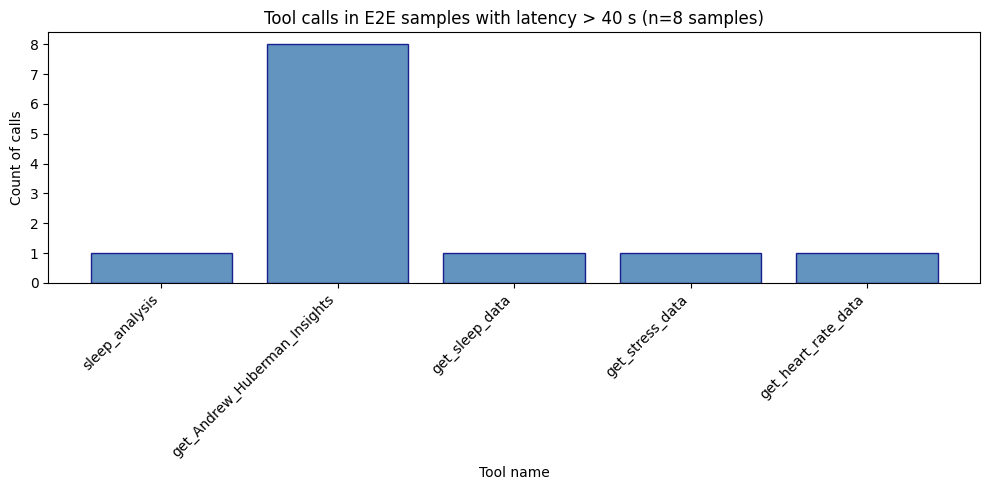

Total tool calls in high-latency samples: 12
Counts by tool: {'sleep_analysis': 1, 'get_Andrew_Huberman_Insights': 8, 'get_sleep_data': 1, 'get_stress_data': 1, 'get_heart_rate_data': 1}


In [185]:
# For each E2E sample with latency > 40s: fetch response from DB, parse tool_calls, plot distribution
import json

timestamps = high["timestamp"].tolist()
if not timestamps:
    print("No high-latency samples; skipping tool-call analysis.")
else:
    # Fetch (timestamp, response) for the high-latency samples
    placeholders = ", ".join(["%s"] * len(timestamps))
    cursor = conn.cursor()
    cursor.execute(
        f"""SELECT timestamp, response
           FROM logging.logger_final
           WHERE timestamp IN ({placeholders})
           AND response IS NOT NULL""",
        [ts for ts in timestamps],
    )
    rows = cursor.fetchall()
    cursor.close()

    def extract_tool_names_from_response(response_str):
        """Parse response JSON (list of messages) and yield each tool call name."""
        if not response_str or (isinstance(response_str, float) and np.isnan(response_str)):
            return
        try:
            messages = json.loads(response_str) if isinstance(response_str, str) else response_str
        except (json.JSONDecodeError, TypeError):
            return
        if not isinstance(messages, list):
            return
        for msg in messages:
            if not isinstance(msg, dict):
                continue
            for tc in msg.get("tool_calls", []):
                if isinstance(tc, dict) and "name" in tc:
                    yield tc["name"]

    # Collect all tool names across high-latency samples
    all_tool_names = []
    for _, (ts, response_str) in enumerate(rows):
        for name in extract_tool_names_from_response(response_str):
            all_tool_names.append(name)

    # Count by tool name
    from collections import Counter
    tool_counts = Counter(all_tool_names)
    tool_names = list(tool_counts.keys())
    counts = [tool_counts[n] for n in tool_names]

    # Distribution chart: tool name (x) vs count (y)
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(tool_names, counts, color="steelblue", edgecolor="navy", alpha=0.85)
    ax.set_xlabel("Tool name")
    ax.set_ylabel("Count of calls")
    ax.set_title(f"Tool calls in E2E samples with latency > {HIGH_LATENCY_THRESHOLD} s (n={len(high)} samples)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    print(f"Total tool calls in high-latency samples: {sum(counts)}")
    print("Counts by tool:", dict(tool_counts))

In [186]:
# Compute p50, p95, p99 (total)
p50, p95, p99 = np.percentile(inference_times, [50, 95, 99])

print("E2E inference time (user submission → response delivery)")
print("\n--- Total ---")
print(f"  p50:  {p50:.2f} s  |  p95:  {p95:.2f} s  |  p99:  {p99:.2f} s  |  n: {len(inference_times)}")
print(f"  min:  {inference_times.min():.2f} s  |  max:  {inference_times.max():.2f} s  |  mean:  {inference_times.mean():.2f} s")

E2E inference time (user submission → response delivery)

--- Total ---
  p50:  6.26 s  |  p95:  27.05 s  |  p99:  81.24 s  |  n: 182
  min:  0.64 s  |  max:  92.13 s  |  mean:  10.42 s


In [187]:
# Monthly trend: use all rows
df_for_monthly = df
print(f"Rows for monthly trend: {len(df_for_monthly)}")
print(df_for_monthly[["timestamp", "inference_time", "month"]].head(10))

Rows for monthly trend: 182
                    timestamp  inference_time    month
192 2025-12-19 18:37:02+00:00       12.252443  2025-12
193 2025-12-22 04:04:24+00:00        8.232297  2025-12
194 2025-12-22 04:05:02+00:00        3.144853  2025-12
195 2025-12-28 17:31:21+00:00        5.369528  2025-12
196 2025-12-28 17:31:40+00:00        4.626146  2025-12
197 2025-12-29 23:11:02+00:00        7.024029  2025-12
198 2025-12-29 23:18:33+00:00        5.885716  2025-12
199 2025-12-31 21:22:36+00:00        7.014846  2025-12
200 2025-12-31 21:24:54+00:00       78.462215  2025-12
201 2026-01-06 19:36:42+00:00       10.311999  2026-01


In [188]:
# p50, p95, p99 per month
monthly = df_for_monthly.groupby("month")["inference_time"].agg(
    p50=lambda x: np.percentile(x, 50),
    p95=lambda x: np.percentile(x, 95),
    p99=lambda x: np.percentile(x, 99),
    count="count",
).reset_index()
print("p50, p95, p99 by month:")
print(monthly.to_string(index=False))

p50, p95, p99 by month:
  month      p50       p95       p99  count
2025-12 7.014846 51.978306 73.165433      9
2026-01 5.738704 15.139847 52.258483     49
2026-02 6.506322 28.479735 81.523788    124


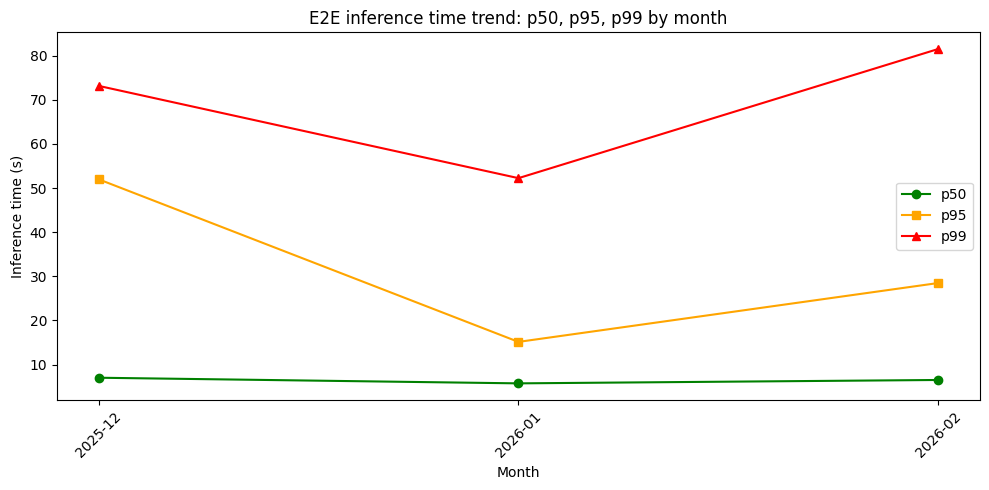

In [189]:
# Trend over time: p50, p95, p99 by month
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(monthly["month"], monthly["p50"], marker="o", label="p50", color="green")
ax.plot(monthly["month"], monthly["p95"], marker="s", label="p95", color="orange")
ax.plot(monthly["month"], monthly["p99"], marker="^", label="p99", color="red")
ax.set_xlabel("Month")
ax.set_ylabel("Inference time (s)")
ax.set_title("E2E inference time trend: p50, p95, p99 by month")
ax.legend()
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

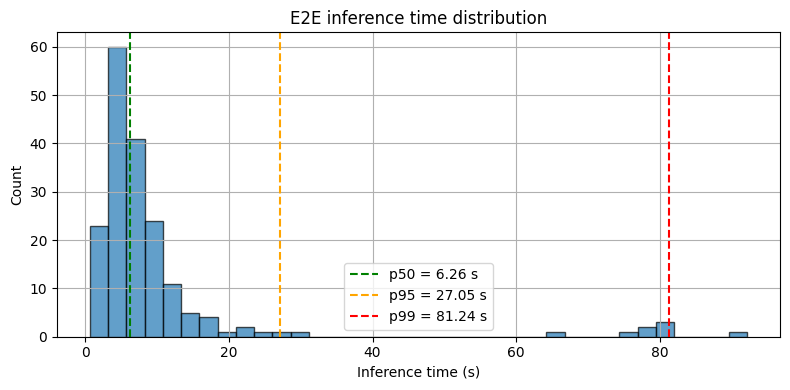


--- Report ---
Total rows: 182
p50: 6.26 s  |  p95: 27.05 s  |  p99: 81.24 s  |  min: 0.64 s  |  max: 92.13 s  |  mean: 10.42 s


In [190]:
# Distribution and report
fig, ax = plt.subplots(figsize=(8, 4))
inference_times.hist(ax=ax, bins=min(50, max(10, len(inference_times) // 5)), edgecolor="black", alpha=0.7)
ax.set_xlabel("Inference time (s)")
ax.set_ylabel("Count")
ax.set_title("E2E inference time distribution")
ax.axvline(p50, color="green", linestyle="--", label=f"p50 = {p50:.2f} s")
ax.axvline(p95, color="orange", linestyle="--", label=f"p95 = {p95:.2f} s")
ax.axvline(p99, color="red", linestyle="--", label=f"p99 = {p99:.2f} s")
ax.legend()
plt.tight_layout()
plt.show()

print("\n--- Report ---")
print(f"Total rows: {len(df)}")
print(f"p50: {p50:.2f} s  |  p95: {p95:.2f} s  |  p99: {p99:.2f} s  |  min: {inference_times.min():.2f} s  |  max: {inference_times.max():.2f} s  |  mean: {inference_times.mean():.2f} s")
try:
    conn.close()
except Exception:
    pass